# PIA de Machine Learning: Predicción de Goles Esperados (xG)
**Objetivo:** Predecir si un tiro terminará en gol (Clasificación Binaria) utilizando un dataset de la Premier League.

## Fase 1: Carga y Preprocesamiento de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

In [2]:
# 1. Carga del Dataset
dataset_path = "epl_2024_2025_match_shots.csv"
print(f"Cargando datos desde: {dataset_path}")

df = pd.read_csv(dataset_path)
print(f"Forma original del dataset: {df.shape}")
df.head()

Cargando datos desde: epl_2024_2025_match_shots.csv
Forma original del dataset: (8746, 23)


,player,isHome,shotType,situation,playerCoordinates,bodyPart,goalMouthLocation,goalMouthCoordinates,blockCoordinates,xg,...,addedTime,timeSeconds,draw,reversedPeriodTime,reversedPeriodTimeSeconds,periodTimeSeconds,incidentType,goalType,match_id,match_date
0,"{""name"": ""Jean-Philippe Mateta"", ""slug"": ""jean...",False,block,assisted,"{""x"": 19.8, ""y"": 37.6, ""z"": 0}",left-foot,low-centre,"{""x"": 0, ""y"": 50.1, ""z"": 19}","{""x"": 16.7, ""y"": 39.5, ""z"": 0}",0.044247,...,NaN,18,"{""start"": {""x"": 37.6, ""y"": 19.8}, ""block"": {""x...",45,2682,18,shot,NaN,12436910,2024-09-01
1,"{""name"": ""Jaden Philogene-Bidace"", ""slug"": ""ja...",True,block,assisted,"{""x"": 7.6, ""y"": 60.1, ""z"": 0}",right-foot,low-centre,"{""x"": 0, ""y"": 49.5, ""z"": 19}","{""x"": 0.90000000000001, ""y"": 51.6, ""z"": 0}",0.137589,...,NaN,24,"{""start"": {""x"": 60.1, ""y"": 7.6}, ""block"": {""x""...",45,2676,24,shot,NaN,12436629,2025-02-22
2,"{""name"": ""Harvey Barnes"", ""firstName"": """", ""la...",True,block,assisted,"{""x"": 20.6, ""y"": 48.7, ""z"": 0}",right-foot,low-left,"{""x"": 0, ""y"": 52.2, ""z"": 19}","{""x"": 13.1, ""y"": 48.4, ""z"": 0}",0.034956,...,NaN,25,"{""start"": {""x"": 48.7, ""y"": 20.6}, ""block"": {""x...",45,2675,25,shot,NaN,12436999,NaN
3,"{""name"": ""Conor Chaplin"", ""firstName"": """", ""la...",True,block,throw-in-set-piece,"{""x"": 14.1, ""y"": 50.3, ""z"": 0}",left-foot,low-centre,"{""x"": 0, ""y"": 50.7, ""z"": 19}","{""x"": 12.4, ""y"": 50.2, ""z"": 0}",0.052231,...,NaN,32,"{""start"": {""x"": 50.3, ""y"": 14.1}, ""block"": {""x...",45,2668,32,shot,NaN,12436538,2025-05-25
4,"{""name"": ""Marcus Rashford"", ""slug"": ""marcus-ra...",False,block,assisted,"{""x"": 14.1, ""y"": 72.9, ""z"": 0}",right-foot,low-centre,"{""x"": 0, ""y"": 51.4, ""z"": 19}","{""x"": 12, ""y"": 69.3, ""z"": 0}",0.047109,...,NaN,33,"{""start"": {""x"": 72.9, ""y"": 14.1}, ""block"": {""x...",45,2667,33,shot,NaN,12436614,2025-04-12


In [3]:
# 2. Definición del Target (Variable Objetivo)
# La columna 'shotType' contiene los resultados del tiro ('miss', 'block', 'save', 'goal', 'post').
# Convertimos a 1 si es 'goal', 0 en caso contrario.
df['is_goal'] = (df['shotType'] == 'goal').astype(int)
print("\nDistribución de la variable objetivo (Goles vs No Goles):")
print(df['is_goal'].value_counts())

# Extraer las coordenadas X y Y del tiro desde la columna 'playerCoordinates'
import json
def parse_coord(coord_str, axis):
    try:
        data = json.loads(coord_str)
        return data.get(axis, 0.0)
    except:
        return 0.0

df['shot_x'] = df['playerCoordinates'].apply(lambda x: parse_coord(x, 'x'))
df['shot_y'] = df['playerCoordinates'].apply(lambda x: parse_coord(x, 'y'))

# Calcular la distancia euclidiana al centro de la portería (asumiendo portería en x=0, y=50)
df['distance_to_goal'] = np.sqrt(df['shot_x']**2 + (df['shot_y'] - 50)**2)

# Seleccionamos las características (features) útiles
features_to_use = ['isHome', 'timeSeconds', 'situation', 'bodyPart', 'shot_x', 'shot_y', 'distance_to_goal']
df_model = df[features_to_use + ['is_goal']].copy()

# Manejo de valores nulos
df_model = df_model.dropna()


Distribución de la variable objetivo (Goles vs No Goles):
is_goal
0    7783
1     963
Name: count, dtype: int64


In [4]:
# 3. Codificación de Variables Categóricas y Escalado
# Variables categóricas: 'situation', 'bodyPart'
cat_cols = ['situation', 'bodyPart']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Separar X e y
X = df_model.drop(columns=['is_goal'])
y = df_model['is_goal']

# División en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nForma final de X_train_scaled:", X_train_scaled.shape)
print("Características finales:", X.columns.tolist())


Forma final de X_train_scaled: (6996, 15)
Características finales: ['isHome', 'timeSeconds', 'shot_x', 'shot_y', 'distance_to_goal', 'situation_corner', 'situation_fast-break', 'situation_free-kick', 'situation_penalty', 'situation_regular', 'situation_set-piece', 'situation_throw-in-set-piece', 'bodyPart_left-foot', 'bodyPart_other', 'bodyPart_right-foot']


## Fase 3: Modelo Base (KNN)
Implementamos un modelo sencillo para establecer la métrica base (baseline).

--- Resultados del Baseline (KNN) ---
Accuracy: 0.8949
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1557
           1       0.57      0.19      0.29       193

    accuracy                           0.89      1750
   macro avg       0.74      0.59      0.62      1750
weighted avg       0.87      0.89      0.87      1750



Text(0.5, 14.722222222222216, 'Predicción')

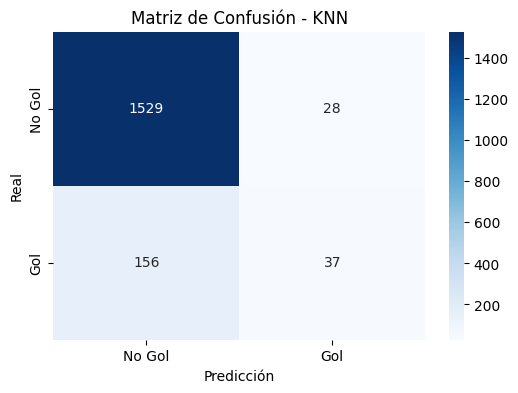

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("--- Resultados del Baseline (KNN) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Opcional: Visualizar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Gol', 'Gol'], yticklabels=['No Gol', 'Gol'])
plt.title("Matriz de Confusión - KNN")
plt.ylabel("Real")
plt.xlabel("Predicción")
# plt.show()

## Fase 4: Modelos Avanzados (Random Forest y SVM)
Como vimos con el KNN, el dataset está desbalanceado (hay muchos más fallos que goles).
Vamos a implementar modelos más robustos configurados para prestarle más atención a la clase minoritaria (los goles).

In [6]:
# 1. Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Usamos class_weight='balanced' para penalizar más los errores en la predicción de goles
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print("--- Resultados de Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

--- Resultados de Random Forest ---
Accuracy: 0.8966
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.94      1557
           1       0.62      0.17      0.26       193

    accuracy                           0.90      1750
   macro avg       0.76      0.58      0.60      1750
weighted avg       0.87      0.90      0.87      1750



In [7]:
# 2. Support Vector Machine (SVM)
from sklearn.svm import SVC

# Usamos kernel 'rbf' (ideal para relaciones no lineales como ángulos y distancias)
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("--- Resultados de SVM ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

--- Resultados de SVM ---
Accuracy: 0.7189
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82      1557
           1       0.23      0.66      0.34       193

    accuracy                           0.72      1750
   macro avg       0.59      0.69      0.58      1750
weighted avg       0.87      0.72      0.77      1750



### Análisis de Importancia de Variables (Feature Importance) - Random Forest
Esto nos ayuda a entender QUÉ hace que un tiro sea gol.

/var/folders/m7/y719fmdd247b72m0_t2221q40000gn/T/ipykernel_38019/838792655.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Característica', data=df_importancias.head(10), palette='viridis')


Text(0.5, 1.0, 'Top 10 Variables Más Importantes para Predecir un Gol (xG)')

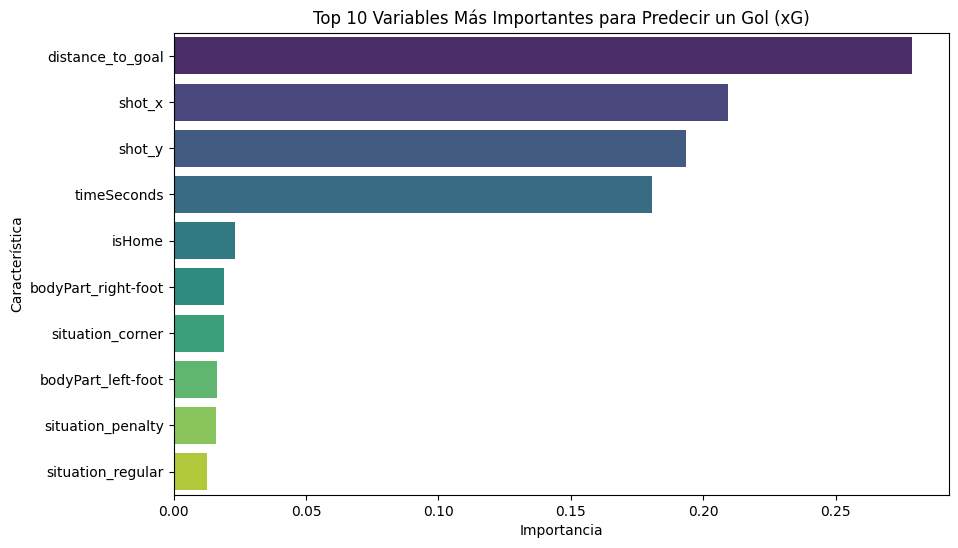

In [8]:
importancias = rf.feature_importances_
nombres_caracteristicas = X.columns
df_importancias = pd.DataFrame({'Característica': nombres_caracteristicas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Característica', data=df_importancias.head(10), palette='viridis')
plt.title('Top 10 Variables Más Importantes para Predecir un Gol (xG)')
# plt.show()